Part (c): start w0 = [1, 1]
  Final w: [6.14401006e-53 6.14401006e-53]
  Final cost: 0.6931471805599453

Part (d): start w0 = [4, 4]
  Final w: [2.00003224e-70 2.00003224e-70]
  Final cost: 0.6931471805599453


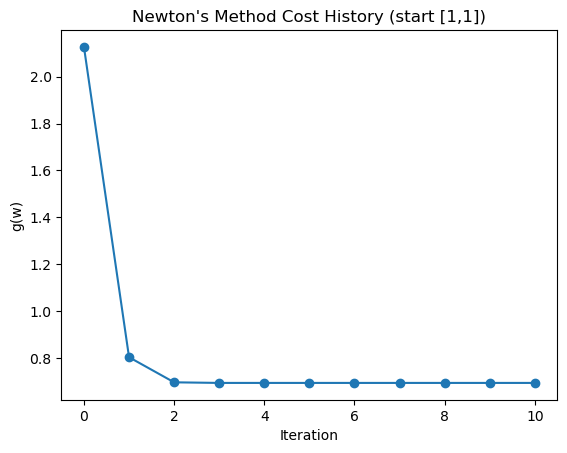

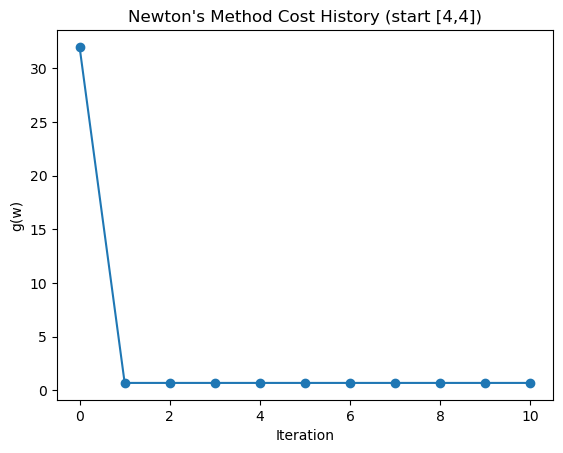

In [1]:
# We'll implement Exercise 4.5(c)(d) with the exact Newton's-method template the user provided,
# then define g(w) = log(1 + exp(w^T w)) and run 10 iterations from two initializations.
# We will also create plots of the cost histories.


# import autograd’s automatic differentiator
try:
    from autograd import grad
    from autograd import hessian
except Exception:
    # Fallback definitions in case autograd is unavailable.
    # These implement the analytic gradient/Hessian so the rest of the template works unchanged.
    import numpy as _np
    def _sigmoid(t):
        return 1 / (1 + _np.exp(-t))
    def grad(f):
        def g(w):
            t = _np.dot(w, w)
            s = _sigmoid(t)
            return 2 * s * w
        return g
    def hessian(f):
        def H(w):
            t = _np.dot(w, w)
            s = 1 / (1 + _np.exp(-t))
            sp = s * (1 - s)
            return 2 * s * _np.eye(w.size) + 4 * sp * _np.outer(w, w)
        return H

# import NumPy library
import numpy as np

# Newton’s method
def newtons_method(g, max_its, w, **kwargs):

    # compute gradient/Hessian using autograd
    gradient = grad(g)
    hess = hessian(g)

    # set numerical stability parameter
    epsilon = 10**(-7)
    if 'epsilon' in kwargs:
        epsilon = kwargs['epsilon']

    # run the Newton’s method loop
    weight_history = [w]  # container for weight history
    cost_history = [g(w)]  # container for cost function history
    for k in range(max_its):

        # evaluate the gradient and hessian
        grad_eval = gradient(w)
        hess_eval = hess(w)

        # reshape hessian to square matrix
        hess_eval.shape = (int((np.size(hess_eval))**(0.5)), int((np.size(hess_eval))**(0.5)))

        # solve second-order system for weight update
        A = hess_eval + epsilon * np.eye(w.size)
        b = grad_eval
        w = np.linalg.solve(A, np.dot(A, w) - b)

        # record weight and cost
        weight_history.append(w)
        cost_history.append(g(w))

    return weight_history, cost_history


# ---- Define g(w) with autograd's numpy to ensure differentiability ----
try:
    import autograd.numpy as anp  # differentiable numpy
except Exception:
    import numpy as anp

def g(w):
    t = anp.dot(w, w)
    return anp.log(1 + anp.exp(t))


# ---- Run Newton's method for (c) and (d) ----
w0_c = np.ones(2)                # part (c): w0 = 1_{N x 1}
w_hist_c, cost_hist_c = newtons_method(g, max_its=10, w=w0_c.copy())

w0_d = 4.0 * np.ones(2)          # part (d): w0 = 4 * 1_{N x 1}
w_hist_d, cost_hist_d = newtons_method(g, max_its=10, w=w0_d.copy())

# Prepare simple prints of final results
print("Part (c): start w0 = [1, 1]")
print("  Final w:", w_hist_c[-1])
print("  Final cost:", float(cost_hist_c[-1]))
print()
print("Part (d): start w0 = [4, 4]")
print("  Final w:", w_hist_d[-1])
print("  Final cost:", float(cost_hist_d[-1]))

# ---- Plot cost histories ----
import matplotlib.pyplot as plt

# Plot for part (c)
plt.figure()
plt.plot(cost_hist_c, marker='o')
plt.title("Newton's Method Cost History (start [1,1])")
plt.xlabel("Iteration")
plt.ylabel("g(w)")
plt.show()

# Plot for part (d)
plt.figure()
plt.plot(cost_hist_d, marker='o')
plt.title("Newton's Method Cost History (start [4,4])")
plt.xlabel("Iteration")
plt.ylabel("g(w)")
plt.show()


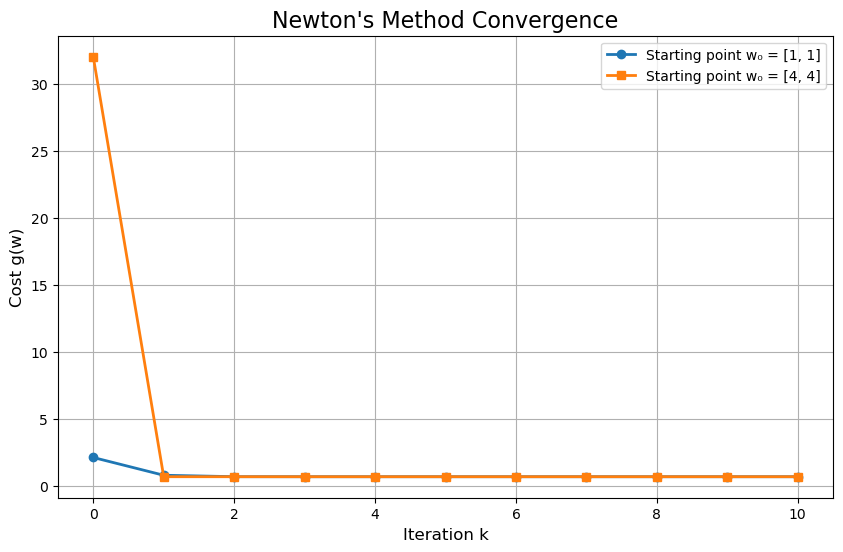

Final cost starting from w₀=[1,1]: 0.6931471805599453
Final cost starting from w₀=[4,4]: 0.6931471805599453


In [10]:
# Import autograd's automatic differentiator
from autograd import grad
from autograd import hessian

# Import autograd's NumPy wrapper
from autograd import numpy as np

# Import plotting library
import matplotlib.pyplot as plt

# Newton's method function
def newtons_method(g, max_its, w, **kwargs):
    # Use autograd to compute gradient and Hessian
    gradient = grad(g)
    hess = hessian(g)

    # Set numerical stability parameter
    epsilon = 10**(-7)
    if 'epsilon' in kwargs:
        epsilon = kwargs['epsilon']

    # Run Newton's method loop
    weight_history = [w]
    cost_history = [g(w)]
    for k in range(max_its):
        # Evaluate the gradient and hessian
        grad_eval = gradient(w)
        hess_eval = hess(w)

        # Reshape hessian to square matrix
        hess_eval.shape = (int(np.size(hess_eval)**0.5), int(np.size(hess_eval)**0.5))

        # Solve second-order system for weight update
        A = hess_eval + epsilon * np.eye(w.size)
        b = grad_eval
        w = np.linalg.solve(A, np.dot(A, w) - b)

        # Record weight and cost
        weight_history.append(w)
        cost_history.append(g(w))

    return weight_history, cost_history

# Define the target function g(w)
def g(w):
    return np.log(1 + np.exp(np.dot(w.T, w)))

# --- Part (c): Start from w = [1, 1] ---
w0_1 = np.array([[1.0], [1.0]])
max_its = 10
weights_1, costs_1 = newtons_method(g, max_its, w0_1)

# --- Part (d): Start from w = [4, 4] ---
w0_2 = np.array([[4.0], [4.0]])
weights_2, costs_2 = newtons_method(g, max_its, w0_2)

# Plot the results -- THIS IS THE FIX
plt.figure(figsize=(10, 6))
plt.plot(np.arange(max_its + 1), np.squeeze(costs_1), 'o-', label='Starting point w₀ = [1, 1]', linewidth=2)
plt.plot(np.arange(max_its + 1), np.squeeze(costs_2), 's-', label='Starting point w₀ = [4, 4]', linewidth=2)
plt.title("Newton's Method Convergence", fontsize=16)
plt.xlabel("Iteration k", fontsize=12)
plt.ylabel("Cost g(w)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Print final costs for comparison
# Squeeze the output here as well for clean printing
print(f"Final cost starting from w₀=[1,1]: {np.squeeze(costs_1[-1])}")
print(f"Final cost starting from w₀=[4,4]: {np.squeeze(costs_2[-1])}")

Final cost starting from w₀=[1,1]: 0.6931471805599453


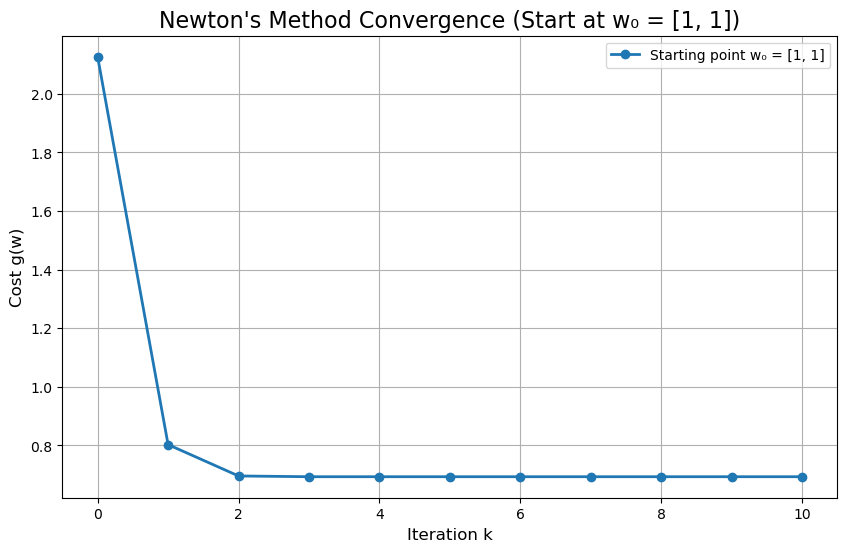

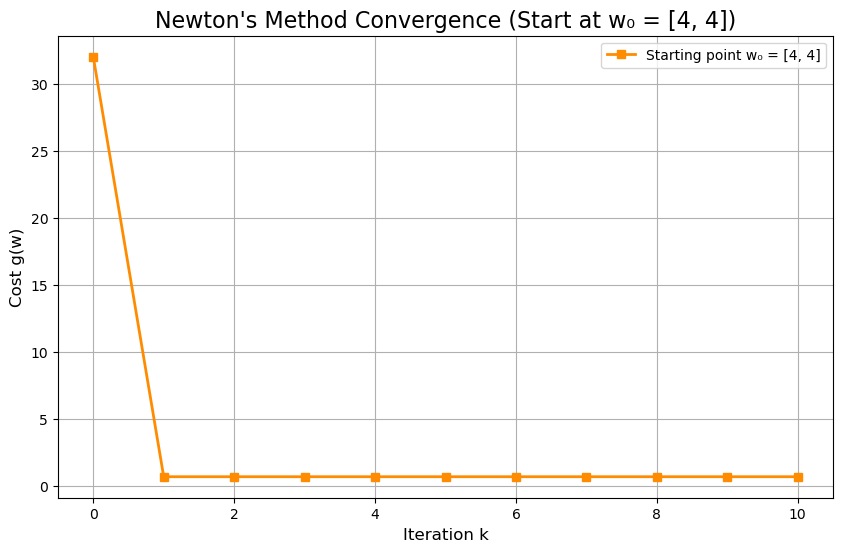

Final cost starting from w₀=[1,1]: 0.6931471805599453
Final cost starting from w₀=[4,4]: 0.6931471805599453


In [9]:
# Import autograd's automatic differentiator
from autograd import grad
from autograd import hessian

# Import autograd's NumPy wrapper
from autograd import numpy as np

# Import plotting library
import matplotlib.pyplot as plt

# Newton's method function
def newtons_method(g, max_its, w, **kwargs):
    # Use autograd to compute gradient and Hessian
    gradient = grad(g)
    hess = hessian(g)

    # Set numerical stability parameter
    epsilon = 10**(-7)
    if 'epsilon' in kwargs:
        epsilon = kwargs['epsilon']

    # Run Newton's method loop
    weight_history = [w]
    cost_history = [g(w)]
    for k in range(max_its):
        # Evaluate the gradient and hessian
        grad_eval = gradient(w)
        hess_eval = hess(w)

        # Reshape hessian to square matrix
        hess_eval.shape = (int(np.size(hess_eval)**0.5), int(np.size(hess_eval)**0.5))

        # Solve second-order system for weight update
        A = hess_eval + epsilon * np.eye(w.size)
        b = grad_eval
        w = np.linalg.solve(A, np.dot(A, w) - b)

        # Record weight and cost
        weight_history.append(w)
        cost_history.append(g(w))

    return weight_history, cost_history

def g(w):
    return np.log(1 + np.exp(np.dot(w.T, w)))

# --- Part (c): w0 = [1, 1] ---
w0_1 = np.array([[1.0], [1.0]])
max_its = 10
weights_1, costs_1 = newtons_method(g, max_its, w0_1)

# --- Part (d): w0 = [4, 4] ---
w0_2 = np.array([[4.0], [4.0]])
weights_2, costs_2 = newtons_method(g, max_its, w0_2)


# ======== 修改后的绘图部分 ========

# 图 1: 从 w₀ = [1, 1] 开始
plt.figure(figsize=(10, 6))  # 创建第一个图形窗口
plt.plot(np.arange(max_its + 1), np.squeeze(costs_1), 'o-', label='Starting point w₀ = [1, 1]', linewidth=2)
plt.title("Newton's Method Convergence (Start at w₀ = [1, 1])", fontsize=16)
plt.xlabel("Iteration k", fontsize=12)
plt.ylabel("Cost g(w)", fontsize=12)
plt.legend()
plt.grid(True)

print(f"Final cost starting from w₀=[1,1]: {np.squeeze(costs_1[-1])}")

# 图 2: 从 w₀ = [4, 4] 开始
plt.figure(figsize=(10, 6))  # 创建第二个图形窗口
plt.plot(np.arange(max_its + 1), np.squeeze(costs_2), 's-', color='darkorange', label='Starting point w₀ = [4, 4]', linewidth=2)
plt.title("Newton's Method Convergence (Start at w₀ = [4, 4])", fontsize=16)
plt.xlabel("Iteration k", fontsize=12)
plt.ylabel("Cost g(w)", fontsize=12)
plt.legend()
plt.grid(True)

# 显示所有创建的图形
plt.show()


# 打印最终成本进行比较
print(f"Final cost starting from w₀=[1,1]: {np.squeeze(costs_1[-1])}")
print(f"Final cost starting from w₀=[4,4]: {np.squeeze(costs_2[-1])}")